EfficientNetB3 Model


In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


In [3]:
# Define constants
DATASET_DIR = r"C:\\Users\\hassa\\OneDrive\\Desktop\\pest project\\Dataset"
IMG_SIZE = (300, 300)  # EfficientNetB3 default input size
BATCH_SIZE = 32
NUM_CLASSES = 6

# Load the dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

Found 40347 files belonging to 6 classes.
Using 32278 files for training.
Found 40347 files belonging to 6 classes.
Using 8069 files for validation.
Class names: ['Disease_Leaf_Blight_Dorsal', 'Disease_Leaf_Blight_Ventral', 'Disease_Mosaic_Dorsal', 'Disease_Mosaic_Ventral', 'Healthy_Dorsal', 'Healthy_Ventral']


In [4]:
# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Details: ", tf.config.list_physical_devices('GPU'))


Num GPUs Available:  0
GPU Details:  []


In [5]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:

# Build the model
base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # Freeze the base model

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

In [6]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("efficientnetb3_model.keras", save_best_only=True)
]

In [8]:

# Train the model
with tf.device("/GPU:1"):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks
    )


Epoch 1/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 3797s 4s/step - accuracy: 0.9212 - loss: 0.2448 - val_accuracy: 0.9989 - val_loss: 0.0051
Epoch 2/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 3970s 4s/step - accuracy: 0.9944 - loss: 0.0186 - val_accuracy: 0.9999 - val_loss: 0.0013
Epoch 3/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 4026s 4s/step - accuracy: 0.9951 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 4.1759e-04
Epoch 4/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 3779s 4s/step - accuracy: 0.9961 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 3.3164e-04
Epoch 5/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 3916s 4s/step - accuracy: 0.9961 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 3.2887e-04
Epoch 6/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 3884s 4s/step - accuracy: 0.9964 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 8.6571e-05
Epoch 7/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 3823s 4s/step - accuracy: 0.9961 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 5.6296e-05
Epoch 8/20
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 4002s 4s/step 

In [9]:

# Evaluate the model
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


253/253 ━━━━━━━━━━━━━━━━━━━━ 745s 3s/step - accuracy: 1.0000 - loss: 7.8252e-06
Validation Accuracy: 100.00%


In [10]:

# Save the model
model.save("efficientnetb3_final_model.keras")



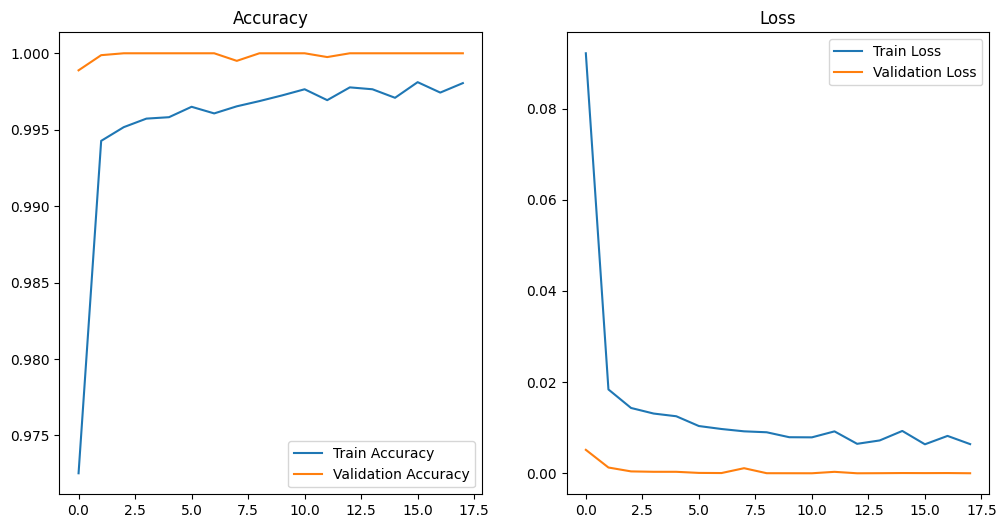

In [11]:
# Plot training history (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [12]:

# Save the model
model.save("efficientnetb3_final_model_20Epoch.keras")

In [13]:

# Save the model
model.save("efficientnetb3_final_model_3.h5")

In [5]:
import tensorflow as tf
model = tf.keras.models.load_model('Models/efficientnetb3_model.keras')
# Evaluate the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,376,067 (43.40 MB)

 Trainable params: 197,510 (771.52 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

 Optimizer params: 395,022 (1.51 MB)

In [ ]:
model.compute_output_shape()
model.input_shape()

TypeError: Sequential.compute_output_shape() missing 1 required positional argument: 'input_shape'

In [8]:
import numpy as np
# Classification Report
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds), axis=-1)

class_names = ['Disease_Leaf_Blight_Dorsal', 'Disease_Leaf_Blight_Ventral', 'Disease_Mosaic_Dorsal', 'Disease_Mosaic_Ventral', 'Healthy_Dorsal', 'Healthy_Ventral']

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

253/253 ━━━━━━━━━━━━━━━━━━━━ 682s 3s/step

Classification Report:


NameError: name 'classification_report' is not defined

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig('Resnet50 Confusion Matrix.jpg')
plt.show()